In [1]:
import scanpy as sc
import anndata as ad
import pandas as pd
import numpy as np
import seaborn as sns
import os
from scipy.stats import median_abs_deviation

DATA_PATH = os.path.join(os.getenv("AGED"), "CBMrepositoryData/perturbational_data/replogle_2022")
SAVE_PATH = os.path.join(os.getenv("MLAB"), "projects/brcameta/projects/sig_recon/data/perturb_seq")

In [4]:
k562_ad = sc.read(os.path.join(DATA_PATH,"K562_essential_raw_singlecell_01.h5ad"))
rpe1_ad = sc.read(os.path.join(DATA_PATH,"rpe1_raw_singlecell_01.h5ad"))

In [3]:
def is_outlier(adata, metric: str, nmads: int):
    M = adata.obs[metric]
    outlier = (M < np.median(M) - nmads * median_abs_deviation(M)) | (
        np.median(M) + nmads * median_abs_deviation(M) < M
    )
    return outlier

# Preprocessing
1. Changing feature names to gene symbols 
2. Basic quality control, filtering of cells and genes according to [best practices](https://www.sc-best-practices.org/preprocessing_visualization/quality_control.html#filtering-low-quality-cells) 
3. Shifted Log normalization according to [best practices](https://www.sc-best-practices.org/preprocessing_visualization/normalization.html#shifted-logarithm)

In [4]:
# Change adata.var
k562_ad.var['ensembl_id'] = k562_ad.var.index.copy()
# Then set gene names as index, if there are duplicates we append a numeric
k562_ad.var.index = k562_ad.var['gene_name'].astype(str)
k562_ad.var_names_make_unique()
k562_ad.var.drop('gene_name', axis=1, inplace=True)

rpe1_ad.var['ensembl_id'] = rpe1_ad.var.index.copy()
# Then set gene names as index, if there are duplicates we append a numeric
rpe1_ad.var.index = rpe1_ad.var['gene_name'].astype(str)
rpe1_ad.var_names_make_unique()
rpe1_ad.var.drop('gene_name', axis=1, inplace=True)

In [5]:
# Changing for raw too
if k562_ad.raw is not None:
    # Get the raw data
    raw_adata = k562_ad.raw.to_adata()
    raw_adata.var['ensembl_id'] = raw_adata.var.index.copy()
    raw_adata.var_names = raw_adata.var['gene_name'].astype(str)
    raw_adata.var_names_make_unique()
    raw_adata.var.drop('gene_name', axis=1, inplace=True)
    
    k562_ad.raw = raw_adata

# For rpe1
if rpe1_ad.raw is not None:
    raw_adata = rpe1_ad.raw.to_adata()
    raw_adata.var['ensembl_id'] = raw_adata.var.index.copy()
    raw_adata.var_names = raw_adata.var['gene_name'].astype(str)
    raw_adata.var_names_make_unique()
    raw_adata.var.drop('gene_name', axis=1, inplace=True)
    
    rpe1_ad.raw = raw_adata

In [6]:
k562_ad.var["mt"] = k562_ad.var_names.str.startswith("MT-")
k562_ad.var["ribo"] = k562_ad.var_names.str.startswith(("RPS", "RPL"))
k562_ad.var["hb"] = k562_ad.var_names.str.contains("^HB[^(P)]")

rpe1_ad.var["mt"] = rpe1_ad.var_names.str.startswith("MT-")
rpe1_ad.var["ribo"] = rpe1_ad.var_names.str.startswith(("RPS", "RPL"))
rpe1_ad.var["hb"] = rpe1_ad.var_names.str.contains("^HB[^(P)]")

## K562 QC

In [7]:
sc.pp.calculate_qc_metrics(
    k562_ad, qc_vars=["mt", "ribo", "hb"], inplace=True, percent_top=[20], log1p=True
)
k562_ad

AnnData object with n_obs × n_vars = 310385 × 8563
    obs: 'gem_group', 'gene', 'gene_id', 'transcript', 'gene_transcript', 'sgID_AB', 'mitopercent', 'UMI_count', 'z_gemgroup_UMI', 'core_scale_factor', 'core_adjusted_UMI_count', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb'
    var: 'chr', 'start', 'end', 'class', 'strand', 'length', 'in_matrix', 'mean', 'std', 'cv', 'fano', 'ensembl_id', 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'

In [8]:
k562_ad.obs.total_counts.min(), k562_ad.obs.total_counts.max(), k562_ad.obs.pct_counts_mt.max()

(np.float32(1782.0), np.float32(64082.0), np.float32(21.522955))

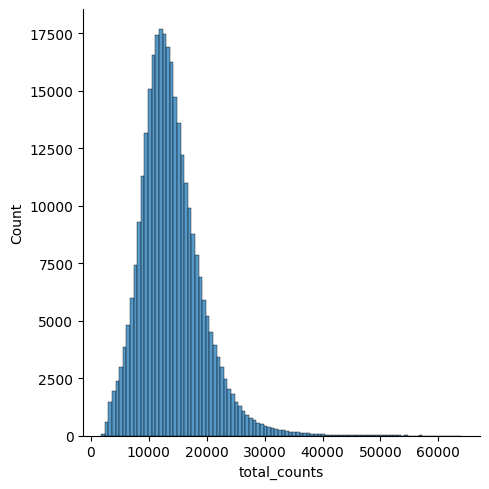

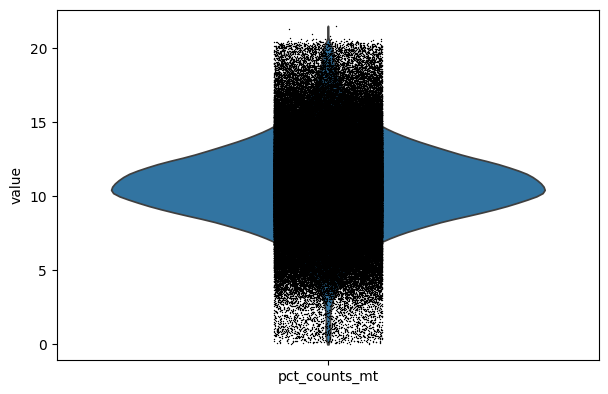

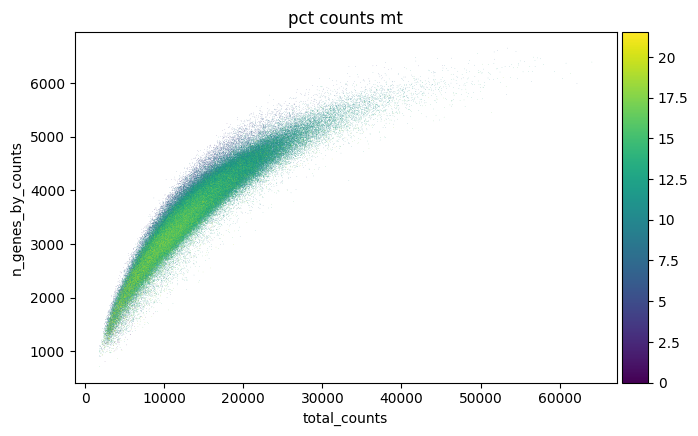

In [9]:
p1 = sns.displot(k562_ad.obs["total_counts"], bins=100, kde=False)
p2 = sc.pl.violin(k562_ad, "pct_counts_mt")
p3 = sc.pl.scatter(k562_ad, "total_counts", "n_genes_by_counts", color="pct_counts_mt")

In [10]:
k562_ad.obs["outlier"] = (
    is_outlier(k562_ad, "log1p_total_counts", 5)
    | is_outlier(k562_ad, "log1p_n_genes_by_counts", 5)
)
k562_ad.obs.outlier.value_counts()

outlier
False    304311
True       6074
Name: count, dtype: int64

In [11]:
k562_ad.obs["mt_outlier"] = is_outlier(k562_ad, "pct_counts_mt", 3)
k562_ad.obs.mt_outlier.value_counts()

mt_outlier
False    284158
True      26227
Name: count, dtype: int64

In [12]:
print(f"Total number of cells: {k562_ad.n_obs}")
k562_ad = k562_ad[(~k562_ad.obs.outlier) & (~k562_ad.obs.mt_outlier)].copy()

print(f"Number of cells after filtering of low quality cells: {k562_ad.n_obs}")

Total number of cells: 310385
Number of cells after filtering of low quality cells: 280090


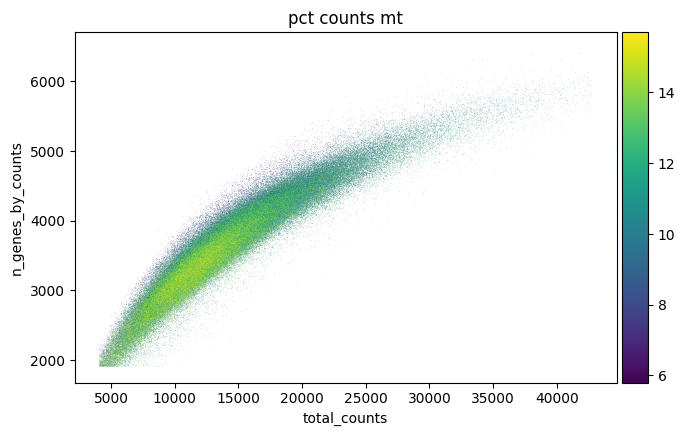

In [13]:
p1 = sc.pl.scatter(k562_ad, "total_counts", "n_genes_by_counts", color="pct_counts_mt")

## RPE1 QC

In [14]:
sc.pp.calculate_qc_metrics(
    rpe1_ad, qc_vars=["mt", "ribo", "hb"], inplace=True, percent_top=[20], log1p=True
)
rpe1_ad

AnnData object with n_obs × n_vars = 247914 × 8749
    obs: 'gem_group', 'gene', 'gene_id', 'transcript', 'gene_transcript', 'sgID_AB', 'mitopercent', 'UMI_count', 'z_gemgroup_UMI', 'core_scale_factor', 'core_adjusted_UMI_count', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb'
    var: 'chr', 'start', 'end', 'class', 'strand', 'length', 'in_matrix', 'mean', 'std', 'cv', 'fano', 'ensembl_id', 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'

In [15]:
rpe1_ad.obs.total_counts.min(), rpe1_ad.obs.total_counts.max(), rpe1_ad.obs.pct_counts_mt.max()

(np.float32(1457.0), np.float32(147863.0), np.float32(11.350994))

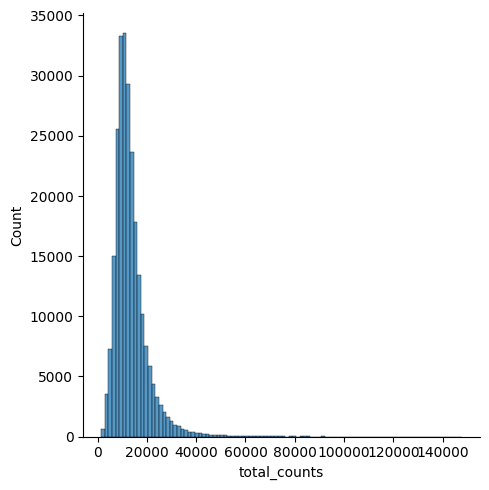

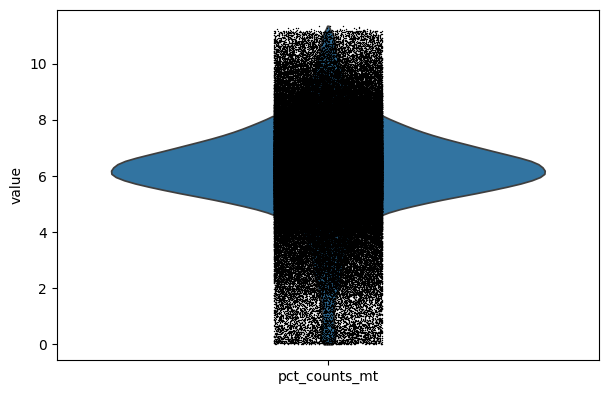

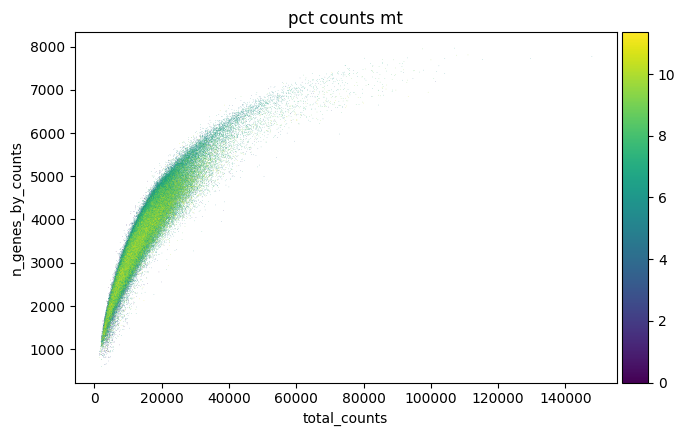

In [16]:
p1 = sns.displot(rpe1_ad.obs["total_counts"], bins=100, kde=False)
p2 = sc.pl.violin(rpe1_ad, "pct_counts_mt")
p3 = sc.pl.scatter(rpe1_ad, "total_counts", "n_genes_by_counts", color="pct_counts_mt")

In [17]:
rpe1_ad.obs["outlier"] = (
    is_outlier(rpe1_ad, "log1p_total_counts", 5)
    | is_outlier(rpe1_ad, "log1p_n_genes_by_counts", 5)
)
rpe1_ad.obs.outlier.value_counts()

outlier
False    244218
True       3696
Name: count, dtype: int64

In [18]:
rpe1_ad.obs["mt_outlier"] = is_outlier(rpe1_ad, "pct_counts_mt", 3)
rpe1_ad.obs.mt_outlier.value_counts()

mt_outlier
False    216770
True      31144
Name: count, dtype: int64

In [19]:
print(f"Total number of cells: {rpe1_ad.n_obs}")
rpe1_ad = rpe1_ad[(~rpe1_ad.obs.outlier) & (~rpe1_ad.obs.mt_outlier)].copy()

print(f"Number of cells after filtering of low quality cells: {rpe1_ad.n_obs}")

Total number of cells: 247914
Number of cells after filtering of low quality cells: 214130


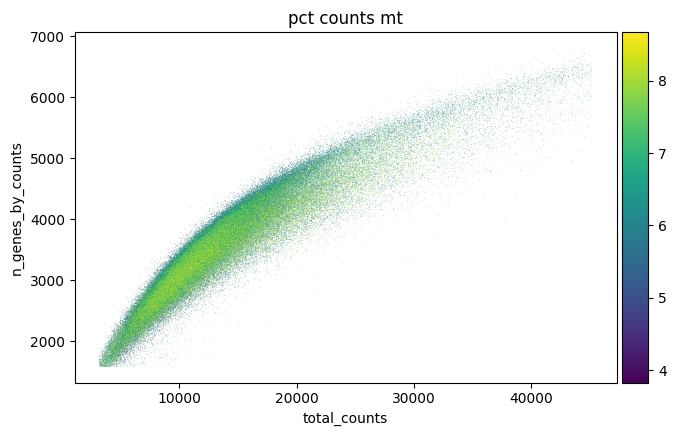

In [20]:
p1 = sc.pl.scatter(rpe1_ad, "total_counts", "n_genes_by_counts", color="pct_counts_mt")

## Normalization

In [21]:
scales_counts = sc.pp.normalize_total(k562_ad, target_sum=None, inplace=False)
# log1p transform
k562_ad.layers["log1p_norm"] = sc.pp.log1p(scales_counts["X"], copy=True)
scales_counts = sc.pp.normalize_total(rpe1_ad, target_sum=None, inplace=False)
# log1p transform
rpe1_ad.layers["log1p_norm"] = sc.pp.log1p(scales_counts["X"], copy=True)

<Axes: ylabel='Count'>

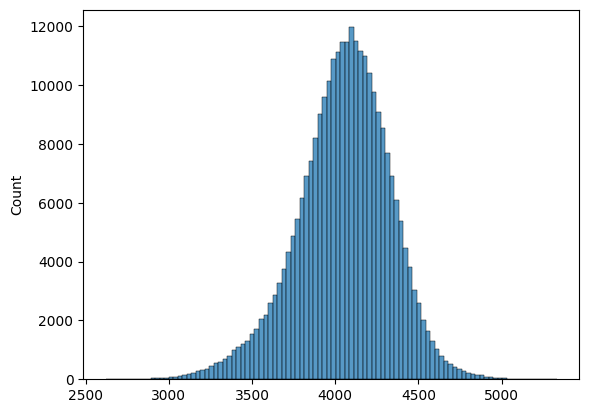

In [22]:
sns.histplot(k562_ad.layers["log1p_norm"].sum(1), bins=100, kde=False)

<Axes: ylabel='Count'>

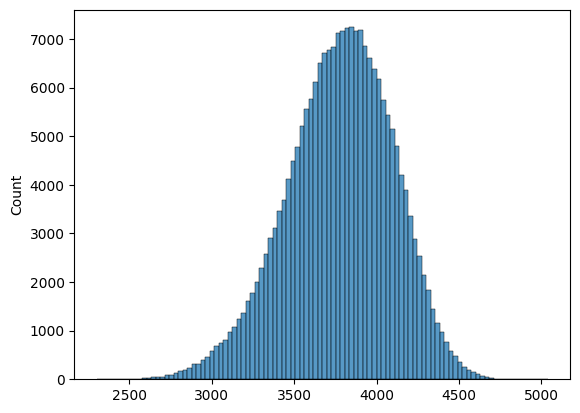

In [23]:
sns.histplot(rpe1_ad.layers["log1p_norm"].sum(1), bins=100, kde=False)

## Saving

In [24]:
k562_ad.uns["Processed"] = True
rpe1_ad.uns["Processed"] = True

In [25]:
k562_ad.write(os.path.join(DATA_PATH,"k562_processed_singlecell.h5ad"))
rpe1_ad.write(os.path.join(DATA_PATH,"rpe1_processed_singlecell.h5ad"))

# Pseudobulk

In [3]:
rpe1_ad = sc.read(os.path.join("/restricted/projectnb/agedisease/CBMrepositoryData/perturbational_data/replogle_2022/rpe1_processed_singlecell.h5ad"))
k562_ad = sc.read(os.path.join("/restricted/projectnb/agedisease/CBMrepositoryData/perturbational_data/replogle_2022/k562_processed_singlecell.h5ad"))

In [52]:
rpe1_ad.obs[rpe1_ad.obs.gene != "non-targeting"][["gene", "gem_group"]].value_counts()

gene    gem_group
SLC1A5  38           50
        25           50
        11           46
        12           45
        34           44
                     ..
AAAS    8             1
        6             1
        5             1
        4             1
        1             1
Name: count, Length: 83048, dtype: int64

In [54]:
rpe1_ad.obs[rpe1_ad.obs.gem_group == 38][["gene"]].value_counts()

gene         
non-targeting    220
SLC1A5            50
MRPL35            30
GTF3C4            28
MRPL36            27
                ... 
ZNF253             0
ZNF143             0
ZNF131             0
ADAT2              0
ACTR6              0
Name: count, Length: 2392, dtype: int64

In [27]:
# 1. Define the grouping variables
# We group by both the CRISPR target and the technical batch (gem_group)
groups = ['gene', 'gem_group'] 

# 2. Use Scanpy's aggregate function (efficient for large arrays)
# This creates a new AnnData where each 'cell' is actually a pseudobulk sample
rpe1_ad_pb = sc.get.aggregate(rpe1_ad, by=groups, func='sum')
k562_ad_pb = sc.get.aggregate(k562_ad, by=groups, func='sum')

In [55]:
rpe1_ad_pb.layers["sum"]

array([[0.0000e+00, 0.0000e+00, 2.0000e+00, ..., 5.7000e+01, 4.0000e+00,
        1.4700e+02],
       [2.0000e+00, 0.0000e+00, 2.0000e+00, ..., 8.1000e+01, 8.0000e+00,
        2.6200e+02],
       [0.0000e+00, 0.0000e+00, 0.0000e+00, ..., 2.6000e+01, 4.0000e+00,
        4.4000e+01],
       ...,
       [2.5800e+02, 3.7000e+01, 1.6200e+02, ..., 7.2980e+03, 1.4020e+03,
        2.0312e+04],
       [2.3600e+02, 3.4000e+01, 1.9600e+02, ..., 6.4830e+03, 1.1750e+03,
        2.0636e+04],
       [1.8100e+02, 2.9000e+01, 1.4700e+02, ..., 5.0230e+03, 7.7700e+02,
        1.6211e+04]], shape=(83104, 8749))

In [29]:
k562_ad_pb

AnnData object with n_obs × n_vars = 82456 × 8563
    obs: 'gene', 'gem_group'
    var: 'chr', 'start', 'end', 'class', 'strand', 'length', 'in_matrix', 'mean', 'std', 'cv', 'fano', 'ensembl_id', 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'
    layers: 'sum'

In [30]:
k562_ad_pb.obs.gene.value_counts()

gene
AARS2            48
AATF             48
non-targeting    48
ZNF718           48
ZNF468           48
                 ..
PPP1R10           6
SEC62             5
RBM22             4
POT1              4
RPL7A             3
Name: count, Length: 2058, dtype: int64

In [31]:
rpe1_ad_pb.obs.gene.value_counts()

gene
ADAM10           56
non-targeting    56
RBM15            56
ZNF718           56
SEC16A           56
                 ..
AURKB             2
INCENP            2
NPAT              2
CDK7              1
LRPPRC            1
Name: count, Length: 2392, dtype: int64

In [5]:
# Cross-tabulation
crosstab = pd.crosstab(rpe1_ad.obs['gene'], rpe1_ad.obs['gem_group'])
print(crosstab)

# How many gem_groups per gene?
gems_per_gene = (crosstab > 0).sum(axis=1)
print(f"\nGem groups per gene:")
print(gems_per_gene.value_counts())

# How many genes per gem_group?
genes_per_gem = (crosstab > 0).sum(axis=0)
print(f"\nGenes per gem group:")
print(genes_per_gem.value_counts())

gem_group       1    2    3    4    5    6    7    8    9    10  ...   47  \
gene                                                             ...        
AAAS             1    0    2    1    1    1    2    1    4    2  ...    2   
AAMP             0    0    0    0    0    1    1    0    0    1  ...    0   
AAR2             0    1    0    0    0    0    0    0    0    0  ...    0   
AARS             0    1    1    1    2    0    1    1    2    2  ...    0   
AARS2            1    3    0    1    2    0    3    1    4    1  ...    1   
...            ...  ...  ...  ...  ...  ...  ...  ...  ...  ...  ...  ...   
ZRANB2           0    1    0    0    0    0    1    1    2    0  ...    1   
ZRSR2            2    5    6    4    7    2    5    5    2    1  ...    6   
ZW10             0    3    0    0    1    1    0    1    0    2  ...    1   
ZWINT            1    1    1    1    0    2    0    3    2    1  ...    0   
non-targeting  193  204  228  221  199  175  207  230  180  219  ...  162   

In [3]:
# Cross-tabulation
crosstab = pd.crosstab(rpe1_ad_pb.obs['gene'], rpe1_ad_pb.obs['gem_group'])
print(crosstab)

# How many gem_groups per gene?
gems_per_gene = (crosstab > 0).sum(axis=1)
print(f"\nGem groups per gene:")
print(gems_per_gene.value_counts())

# How many genes per gem_group?
genes_per_gem = (crosstab > 0).sum(axis=0)
print(f"\nGenes per gem group:")
print(genes_per_gem.value_counts())

gem_group      1  2  3  4  5  6  7  8  9  10  ...  47  48  49  50  51  52  53  \
gene                                          ...                               
AAAS           1  0  1  1  1  1  1  1  1   1  ...   1   0   1   1   1   1   1   
AAMP           0  0  0  0  0  1  1  0  0   1  ...   0   0   1   0   1   0   0   
AAR2           0  1  0  0  0  0  0  0  0   0  ...   0   0   1   1   0   1   0   
AARS           0  0  1  1  1  0  0  1  1   1  ...   0   0   0   0   0   1   0   
AARS2          1  1  0  1  1  0  1  0  1   1  ...   1   1   0   0   1   1   1   
...           .. .. .. .. .. .. .. .. ..  ..  ...  ..  ..  ..  ..  ..  ..  ..   
ZRANB2         0  1  0  0  0  0  1  1  1   0  ...   1   0   1   0   0   1   1   
ZRSR2          1  1  1  1  1  1  1  1  1   1  ...   1   1   1   1   1   1   1   
ZW10           0  1  0  0  1  1  0  1  0   1  ...   1   1   1   1   0   1   0   
ZWINT          1  1  1  1  0  1  0  1  1   1  ...   0   1   0   0   1   1   0   
non-targeting  1  1  1  1  1

In [32]:
k562_ad_pb.write(os.path.join(SAVE_PATH,"k562_processed_pb.h5ad"))
rpe1_ad_pb.write(os.path.join(SAVE_PATH,"rpe1_processed_pb.h5ad"))

In [ ]:
counts_df = pd.DataFrame(k562_ad_pb.layers["sum"], 
                         index=k562_ad_pb.obs_names, 
                         columns=k562_ad_pb.var_names).T
counts_df.to_csv(os.path.join(SAVE_PATH,"k562_processed_pb.csv"))
k562_ad_pb.obs.to_csv(os.path.join(SAVE_PATH,("k562_processed_pb_metadata.csv"))

counts_df = pd.DataFrame(rpe1_ad_pb.layers["sum"], 
                         index=rpe1_ad_pb.obs_names, 
                         columns=rpe1_ad_pb.var_names).T
counts_df.to_csv(os.path.join(SAVE_PATH,("rpe1_processed_pb.csv"))
rpe1_ad_pb.obs.to_csv(os.path.join(SAVE_PATH,("rpe1_processed_pb_metadata.csv"))

In [4]:
# aggregate by gene only
rpe1_ad_pb = sc.get.aggregate(rpe1_ad, by='gene', func='sum')
k562_ad_pb = sc.get.aggregate(k562_ad, by='gene', func='sum')

In [7]:
rpe1_ad_pb.obs.gene.value_counts()

gene
non-targeting    1
AAAS             1
AAMP             1
AAR2             1
AARS             1
                ..
ABHD11           1
ABCG1            1
ABCF1            1
ABCE1            1
ABCB10           1
Name: count, Length: 2392, dtype: int64

In [6]:
k562_ad_pb

AnnData object with n_obs × n_vars = 2058 × 8563
    obs: 'gene'
    var: 'chr', 'start', 'end', 'class', 'strand', 'length', 'in_matrix', 'mean', 'std', 'cv', 'fano', 'ensembl_id', 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'
    layers: 'sum'

In [9]:
rpe1_ad.obs.columns

Index(['gem_group', 'gene', 'gene_id', 'transcript', 'gene_transcript',
       'sgID_AB', 'mitopercent', 'UMI_count', 'z_gemgroup_UMI',
       'core_scale_factor', 'core_adjusted_UMI_count', 'n_genes_by_counts',
       'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts',
       'pct_counts_in_top_20_genes', 'total_counts_mt',
       'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo',
       'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb',
       'log1p_total_counts_hb', 'pct_counts_hb', 'outlier', 'mt_outlier'],
      dtype='object')